In [1]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sleap
import numpy as np
import datetime

from matplotlib.patches import ConnectionPatch
from pathlib import Path

In [2]:
import sleap_roots_training

from sleap_roots_training.evaluate import main, predictions_viz_from_sleap_files, fetch_sweep_metrics

In [3]:
# Constants for W&B initialization
ENTITY_NAME = "eberrigan-salk-institute-for-biological-studies"
PROJECT_NAME = "sleap-roots"
REGISTRY = "sleap-roots-models"
JOB_TYPE = "sweep"
EXPERIMENT_NAME = "20250529_wheat_seminal_sweep"

# Constants for artifact creation
DESCRIPTION = "wheat 5-14 DAG seminal roots with 6 nodes with varying input scaling"
TAGS = ["wheat5-14DAG", "seminal", "6nodes", "wheat", "input_scaling"]
COLLECTION_NAME = EXPERIMENT_NAME
LABEL_COUNTS_CSV_PATH = "D:/SLEAP/20250529_seminal_root_generalist/wheat/train_test_splits.csv"
ARTIFACT_NAME = "wheat_seminal_6nodes_input_scaling_sweep"

In [4]:
# Model and group configuration
# https://wandb.ai/eberrigan-salk-institute-for-biological-studies/sleap-roots/groups/20250529_wheat_seminal_sweep/artifacts
MODEL_GROUP = "20250529_wheat_seminal_sweep" # This is the group name for the sweep
VERSIONS = ["000", "001", "002"] # Each model artifact has the name "{MODEL_GROUP}_v{VERSION}"

In [5]:
SWEEP_IDS = ["xmmszsc2", "872vxc35", "vdi0d9gn"]
TARGET_METRICS = ["dist_p50", "dist_p90", "dist_p95", "dist_p99", "dist_avg", "dist_std", "vis_prec", "vis_recall", "oks_map", "oks_mar"]

In [6]:
sleap_roots_training.reset_config()

Configuration updated successfully at e:\repositories\sleap-roots-training\sleap_roots_training\config.yaml.
Configuration has been reset to default values.


In [7]:
sleap_roots_training.update_config(entity_name=ENTITY_NAME, project_name=PROJECT_NAME, registry=REGISTRY, experiment_name=EXPERIMENT_NAME)

Configuration updated successfully at e:\repositories\sleap-roots-training\sleap_roots_training\config.yaml.
CONFIG updated to {'project_name': 'sleap-roots', 'entity_name': 'eberrigan-salk-institute-for-biological-studies', 'experiment_name': '20250529_wheat_seminal_sweep', 'registry': 'sleap-roots-models', 'collection_name': None, 'job_type': None}.


In [8]:
# Make directory for experiment
Path(EXPERIMENT_NAME).mkdir(exist_ok=True, parents=True)

In [9]:
datetime_str = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

In [10]:
sweep_df = fetch_sweep_metrics(
    sweep_ids=SWEEP_IDS,
    target_metrics=TARGET_METRICS,
    include_config=True,
)

In [11]:
sweep_df

,run_id,name,group,sweep_id,dist_p50,dist_p90,dist_p95,dist_p99,dist_avg,dist_std,...,config/name,config/model,config/outputs,config/version,config/filename,config/config_path,config/description,config/optimization,config/sleap_version,config/data.preprocessing.input_scaling
0,con8micx,20250529_wheat_seminal_sweep_training_v002,20250529_wheat_seminal_sweep,xmmszsc2,0.704381,3.940261,5.830742,15.356528,1.669611,2.780363,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,2,D:\SLEAP\20250529_seminal_root_generalist\whea...,D:/SLEAP/20250529_seminal_root_generalist/whea...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.3.4,1.00
1,s3v00u0t,20250529_wheat_seminal_sweep_training_v002,20250529_wheat_seminal_sweep,xmmszsc2,0.796252,3.886312,5.955944,17.557036,1.723459,3.057318,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,2,D:\SLEAP\20250529_seminal_root_generalist\whea...,D:/SLEAP/20250529_seminal_root_generalist/whea...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.3.4,0.75
2,dxlzwmfn,20250529_wheat_seminal_sweep_training_v002,20250529_wheat_seminal_sweep,xmmszsc2,0.804402,3.394079,4.782251,16.945392,1.680499,3.089903,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,2,D:\SLEAP\20250529_seminal_root_generalist\whea...,D:/SLEAP/20250529_seminal_root_generalist/whea...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.3.4,0.50
3,bjk4r944,20250529_wheat_seminal_sweep_training_v000,20250529_wheat_seminal_sweep,872vxc35,0.663849,4.045187,5.241164,10.432437,1.514734,2.087262,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,0,D:\SLEAP\20250529_seminal_root_generalist\whea...,D:/SLEAP/20250529_seminal_root_generalist/whea...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.3.4,1.00
4,emc3plww,20250529_wheat_seminal_sweep_training_v000,20250529_wheat_seminal_sweep,872vxc35,0.597359,4.052707,5.637420,14.915988,1.626795,2.792827,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,0,D:\SLEAP\20250529_seminal_root_generalist\whea...,D:/SLEAP/20250529_seminal_root_generalist/whea...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.3.4,0.75
5,sxyykxsq,20250529_wheat_seminal_sweep_training_v000,20250529_wheat_seminal_sweep,872vxc35,0.678616,5.532339,9.029054,17.528975,2.099433,3.470941,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,0,D:\SLEAP\20250529_seminal_root_generalist\whea...,D:/SLEAP/20250529_seminal_root_generalist/whea...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.3.4,0.50
6,x25z8g2x,20250529_wheat_seminal_sweep_training_v001,20250529_wheat_seminal_sweep,vdi0d9gn,0.632601,3.778853,7.106602,18.366862,1.764049,3.819487,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,1,D:\SLEAP\20250529_seminal_root_generalist\whea...,D:/SLEAP/20250529_seminal_root_generalist/whea...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.3.4,1.00
7,vhaoz3wz,20250529_wheat_seminal_sweep_training_v001,20250529_wheat_seminal_sweep,vdi0d9gn,0.623036,2.782256,4.540640,11.241122,1.324564,2.383105,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,1,D:\SLEAP\20250529_seminal_root_generalist\whea...,D:/SLEAP/20250529_seminal_root_generalist/whea...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.3.4,0.75
8,bvvvq88s,20250529_wheat_seminal_sweep_training_v001,20250529_wheat_seminal_sweep,vdi0d9gn,0.681581,3.389443,6.938262,14.309509,1.609579,2.617699,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,1,D:\SLEAP\20250529_seminal_root_generalist\whea...,D:/SLEAP/20250529_seminal_root_generalist/whea...,,"{'epoc

In [12]:
sweep_csv_path = Path(EXPERIMENT_NAME) / f"sweep_metrics_{datetime_str}.csv"
sweep_df.to_csv(sweep_csv_path, index=False)
print(f"Sweep metrics saved to {sweep_csv_path}")

Sweep metrics saved to 20250529_wheat_seminal_sweep\sweep_metrics_2025-05-30_20-54-26.csv


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


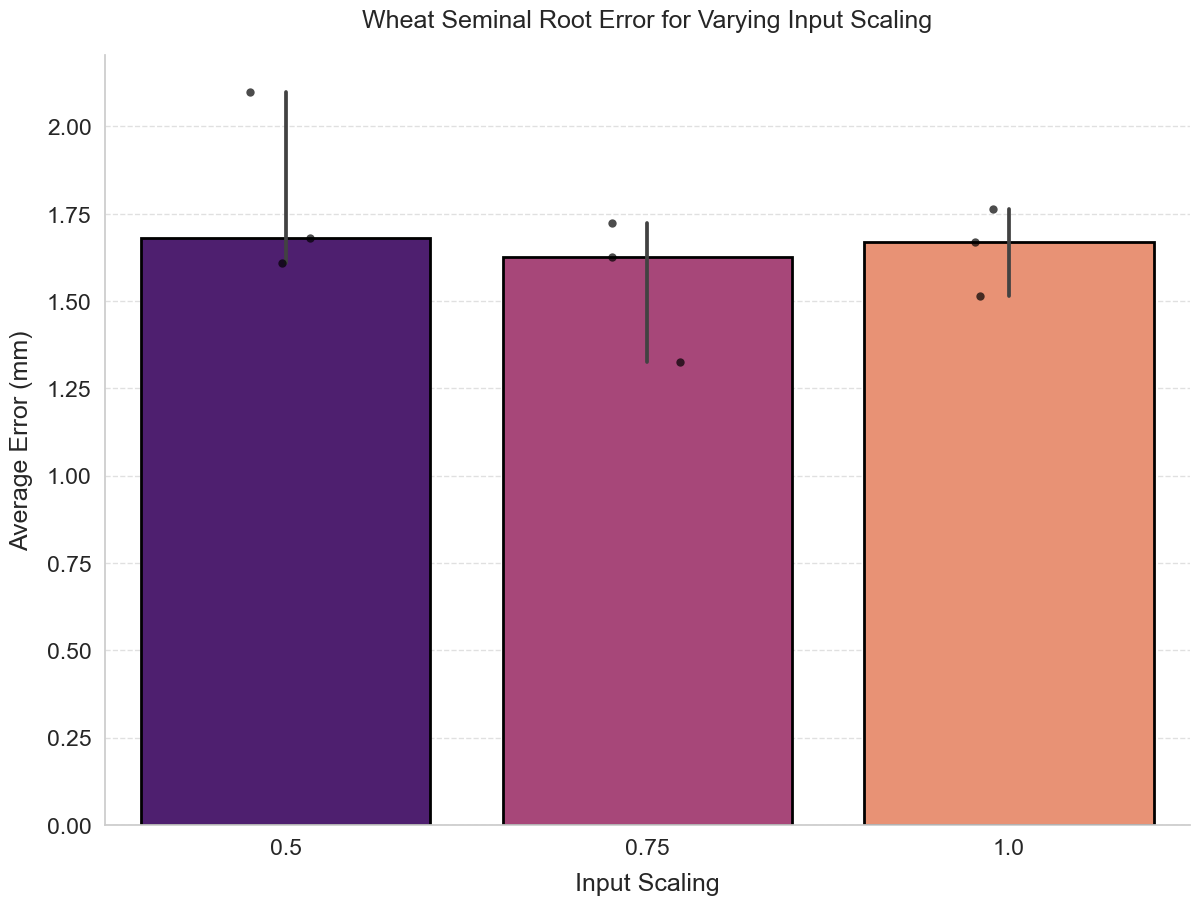

Plot saved to 20250529_wheat_seminal_sweep\2025-05-30_20-54-26_input_scaling_sweep_eval.png


In [13]:
# ========== SETTINGS ==========
font_settings = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 26
}


plt.rcParams.update(font_settings)
sns.set_theme(style="whitegrid", font_scale=1.5)

# ========== LOAD LABEL COUNTS ==========
label_csv_path = LABEL_COUNTS_CSV_PATH
df_labels = pd.read_csv(label_csv_path)

# Sum train + val + test labels per crop using version 0 since all versions have the same ratios of train/val/test
df_labels_v0 = df_labels[df_labels["version"] == 0]
total_labeled_per_crop = df_labels_v0["labeled_frames"].sum()

data = sweep_df.copy()

# ========== PLOTTING ==========
plt.figure(figsize=(14, 10))

# Barplot (median dist_avg)
ax = sns.barplot(
    data=sweep_df, x="config/data.preprocessing.input_scaling", y="dist_avg",
    estimator=np.median,
    palette="magma", edgecolor="black", linewidth=2
)

# Overlay raw points
sns.stripplot(
    data=sweep_df, x="config/data.preprocessing.input_scaling", y="dist_avg",
    color="black", size=6, alpha=0.7, jitter=True
)

# Title and axis labels
plt.title("Wheat Seminal Root Error for Varying Input Scaling", pad=20)
plt.xlabel("Input Scaling", labelpad=10)
plt.ylabel("Average Error (mm)", labelpad=10)

# Readability adjustments
# plt.xticks(rotation=45, ha="right")
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.6)


# Save
plot_file_path = Path(EXPERIMENT_NAME) / f"{datetime_str}_input_scaling_sweep_eval.png"
plt.savefig(plot_file_path, dpi=600, bbox_inches="tight", transparent=True)
plt.show()
print(f"Plot saved to {plot_file_path}")

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


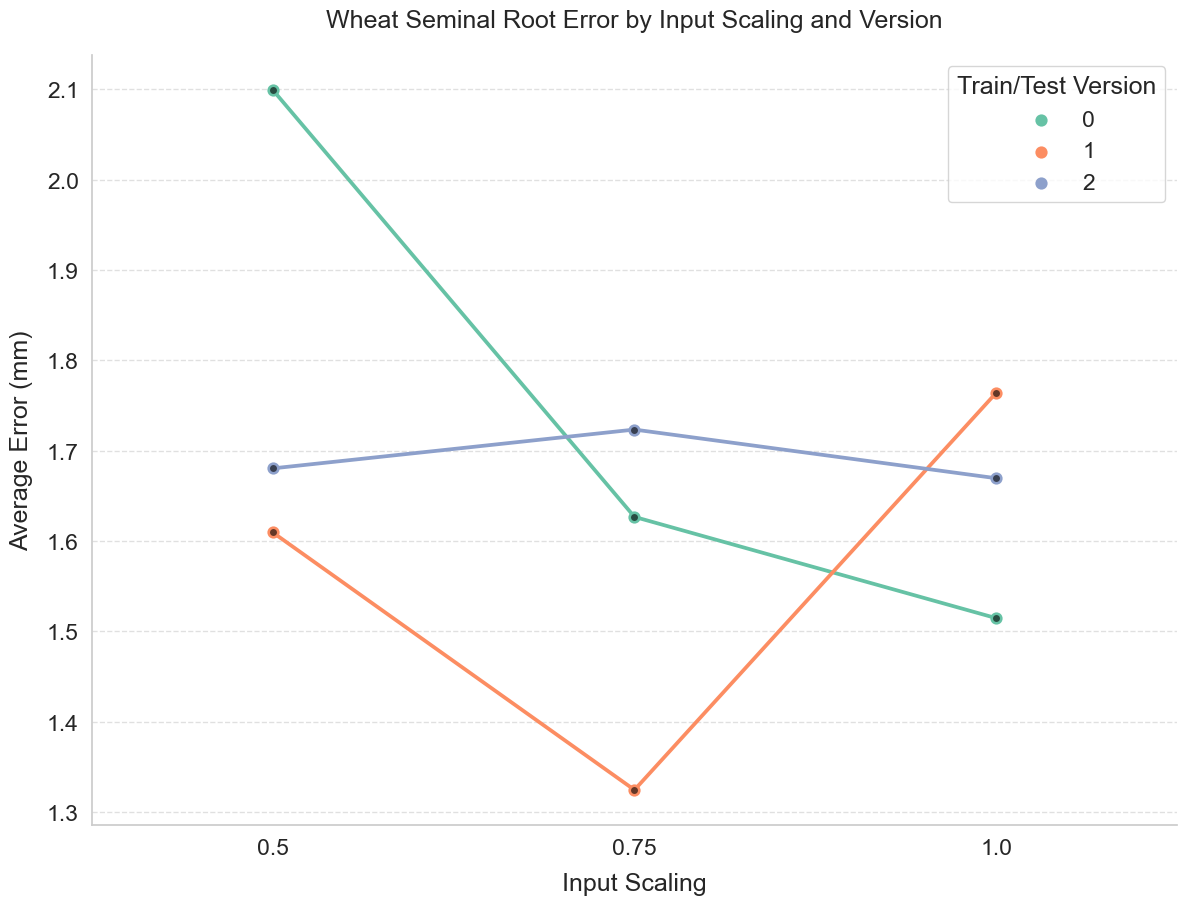

Plot saved to 20250529_wheat_seminal_sweep\2025-05-30_20-54-26_input_scaling_sweep_eval_version.png


In [14]:
# ========== SETTINGS ==========
font_settings = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 26
}


plt.rcParams.update(font_settings)
sns.set_theme(style="whitegrid", font_scale=1.5)

# ========== LOAD LABEL COUNTS ==========
label_csv_path = LABEL_COUNTS_CSV_PATH
df_labels = pd.read_csv(label_csv_path)

# Sum train + val + test labels per crop using version 0 since all versions have the same ratios of train/val/test
df_labels_v0 = df_labels[df_labels["version"] == 0]
total_labeled_per_crop = df_labels_v0["labeled_frames"].sum()

data = sweep_df.copy()

# ========== PLOTTING ==========
plt.figure(figsize=(14, 10))

sns.pointplot(
    data=data,
    x="config/data.preprocessing.input_scaling",
    y="dist_avg",
    hue="config/version",
    palette="Set2",
    markers="o",
    linestyles="-",
    errorbar=None
)

sns.stripplot(
    data=data,
    x="config/data.preprocessing.input_scaling",
    y="dist_avg",
    color="black",
    size=5,
    alpha=0.6,
    jitter=False,
)

plt.title("Wheat Seminal Root Error by Input Scaling and Version", pad=20)
plt.xlabel("Input Scaling", labelpad=10)
plt.ylabel("Average Error (mm)", labelpad=10)

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Train/Test Version")

plot_file_path = Path(EXPERIMENT_NAME) / f"{datetime_str}_input_scaling_sweep_eval_version.png"
plt.savefig(plot_file_path, dpi=600, bbox_inches="tight", transparent=True)
plt.show()
print(f"Plot saved to {plot_file_path}")


In [15]:
from scipy.stats import friedmanchisquare

# Pivot data: rows = version, columns = input_scaling
pivot = sweep_df.pivot_table(
    index="config/version",
    columns="config/data.preprocessing.input_scaling",
    values="dist_avg"
)

# Apply Friedman test
stat, p = friedmanchisquare(*[pivot[col] for col in pivot.columns])

print(f"Friedman test statistic: {stat:.3f}, p-value: {p:.4f}")
if p < 0.05:
    print("Significant difference detected between input scalings.")
else:
    print("No significant difference between input scalings.")

# from itertools import combinations
# from scipy.stats import wilcoxon

# scaling_pairs = combinations(pivot.columns, 2)

# for a, b in scaling_pairs:
#     stat, p = wilcoxon(pivot[a], pivot[b])
#     print(f"{a} vs {b}: p = {p:.4f}")

Friedman test statistic: 0.667, p-value: 0.7165
No significant difference between input scalings.


In [16]:
# selected_version = "000"
# model_name = f"{MODEL_GROUP}_v{selected_version}"
# frame_index = 6

# # Paths and settings
# prediction_files = []
# test_group_names = []

# for group in GROUPS:
#     test_set = f"{group}_v{selected_version}"
#     run_dir = Path(EXPERIMENT_NAME) / f"{model_name}_on_{test_set}_{datetime_str}"
#     prediction_path = run_dir / f"{model_name}_on_{test_set}_test_predictions.slp"

#     if prediction_path.exists():
#         prediction_files.append(prediction_path.as_posix())
#         # Clean group name (remove suffix)
#         test_group_names.append(group.split("_")[-1])
#     else:
#         print(f"Missing prediction file: {prediction_path}")

# # Call the grid visualization function
# predictions_viz_from_sleap_files(
#     prediction_files_grid=[prediction_files],  # wrap in another list: 1 row
#     test_group_names=test_group_names, # column label
#     model_names=[model_name],  # row label
#     output_path=Path(EXPERIMENT_NAME) / f"{datetime_str}_predictions_grid_frame{frame_index}.png",
#     frame_idx=frame_index,
#     figsize_scale=5,
#     dpi=300,
#     transparent=False,
#     font_settings=font_settings,
#     colormap="magma",
#     spacing={
#         "left": 0.00,
#         "right": 1.00,
#         "top": 1.00,
#         "bottom": 0.00,
#         "wspace": 0.0,
#         "hspace": 0.0,
#         }
# )


In [19]:
# === Initialize the W&B run ===
add_files_run = wandb.init(
    project=PROJECT_NAME,
    entity=ENTITY_NAME,
    job_type="add_files_to_artifact"
)

# === Use existing artifact and download its contents ===
# metrics_artifact = add_files_run.use_artifact(f"{ARTIFACT_NAME}:latest", type="metrics")
# artifact_dir = Path(metrics_artifact.download())
# print(f"Artifact downloaded to: {artifact_dir}")

# === Create a new artifact ===
new_metrics_artifact = wandb.Artifact(name=ARTIFACT_NAME, type="metrics")

# === Add generalizable model plots ===
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_input_scaling_sweep_eval.png").as_posix())
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_input_scaling_sweep_eval_version.png").as_posix())

# === Add associated CSVs ===
new_metrics_artifact.add_file((Path(label_csv_path)).as_posix())
new_metrics_artifact.add_file((Path(sweep_csv_path)).as_posix())

# === Add existing artifact contents ===
# for file_path in artifact_dir.iterdir():
#     new_metrics_artifact.add_file(file_path)

# === Log and finish ===
add_files_run.log_artifact(new_metrics_artifact)
add_files_run.finish()